# Desafío 3

Alumno: Rodrigo Mesa Marchi (a2016)

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout,Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense, GRU
from tensorflow.keras.losses import SparseCategoricalCrossentropy
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding
from keras.models import Model, Sequential

import matplotlib.pyplot as plt
import seaborn as sns

2025-09-28 11:14:35.981953: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1)Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.

Para esta ejercicio, utilizaremos otro libro al elegido por el notebook original. En este caso, utilizaremos el libro crimen y castigo. Haremos uso del preprocesamiento del notebook original

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

In [ ]:
raw_html = urllib.request.urlopen('https://www.textos.info/fiodor-mijailovich-dostoyevski/crimen-y-castigo/ebook')
raw_html = raw_html.read()

# Parsear artículo, 'lxml' es el parser a utilizar
article_html = bs.BeautifulSoup(raw_html, 'lxml')

# Encontrar todos los párrafos del HTML (bajo el tag <p>)
# y tenerlos disponible como lista
article_paragraphs = article_html.find_all('p')

article_text = ''

for para in article_paragraphs:
    article_text += para.text + ' '
print(len(article_text))
# pasar todo el texto a minúscula
article_text = article_text.lower().replace('\n', ' ') # Quitamos enter
print(len(article_text))

1041003
1028979


## 2) Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.

In [4]:
article_text = article_text[:200000] # Nos quedamos con la primera mitad del libro, sino falla el entrenamiento

In [5]:
# en article text se encuentra el texto de todo el libro
article_text[:1000]

' una tarde muy calurosa de principios de julio, salió del cuartito queocupaba, junto al techo de una gran casa de cinco pisos, un joven, que,lentamente y con aire irresoluto, se dirigió hacia el puente de k***. tuvo suerte, al bajar la escalera, de no encontrarse a su patrona quehabitaba en el piso cuarto, y cuya cocina, que tenía la puertaconstantemente sin cerrar, daba a la escalera. cuando salía el joven,había de pasar forzosamente bajo el fuego del enemigo, y cada vez queesto ocurría experimentaba aquél una molesta sensación de temor que,humillándole, le hacía fruncir el entrecejo. tenía una deuda no pequeñacon su patrona y le daba vergüenza el encontrarla. no quiere esto decir que la desgracia le intimidase o abatiese; nadade eso; pero la verdad era que, desde hacía algún tiempo, se hallaba encierto estado de irritación nerviosa, rayano con la hipocondría. afuerza de aislarse y de encerrarse en sí mismo, acabó por huir, nosolamente de su patrona, sino de toda relación con sus sem

In [6]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [7]:
# en este caso el vocabulario es el conjunto único de caracteres que existe en todo el texto
chars_vocab = set(article_text)

In [8]:
# Construimos los dicionarios que asignan índices a caracteres y viceversa.
# El diccionario `char2idx` servirá como tokenizador.
char2idx = {k: v for v,k in enumerate(chars_vocab)}
idx2char = {v: k for k,v in char2idx.items()}

###  Tokenizar

In [9]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in article_text]

### Organizando y estructurando el dataset

In [10]:
# separaremos el dataset entre entrenamiento y validación.
# `p_val` será la proporción del corpus que se reservará para validación
# `num_val` es la cantidad de secuencias de tamaño `max_context_size` que se usará en validación
p_val = 0.1
num_val = int(np.ceil(len(tokenized_text)*p_val/max_context_size))
# separamos la porción de texto utilizada en entrenamiento de la de validación.
train_text = tokenized_text[:-num_val*max_context_size]
val_text = tokenized_text[-num_val*max_context_size:]
tokenized_sentences_val = [val_text[init*max_context_size:init*(max_context_size+1)] for init in range(num_val)]
tokenized_sentences_train = [train_text[init:init+max_context_size] for init in range(len(train_text)-max_context_size+1)]
X = np.array(tokenized_sentences_train[:-1])
y = np.array(tokenized_sentences_train[1:])

In [11]:
vocab_size = len(chars_vocab)

## 3) Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.

En esta sección, haremos el entrenamiento de una serie de modelos similares, realizando la variación de la capa intermedia del modelo. Con esto, evaluaremos el desempeño de las distintas capas: SimpleRNN, LSTM y GRU

In [12]:
def generate_rnn_model():
    model = Sequential()
    model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
    model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

def generate_lstm_model():
    model = Sequential()
    model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
    model.add(LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

def generate_gru_model():
    model = Sequential()
    model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
    model.add(GRU(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
    return model

Utilizaremos el callback ya desarrollado para la perplexity. Agregamos variable para poder nombrar modelo de salida

In [13]:
class PplCallback(keras.callbacks.Callback):

    '''
    Este callback es una solución ad-hoc para calcular al final de cada epoch de
    entrenamiento la métrica de Perplejidad sobre un conjunto de datos de validación.
    La perplejidad es una métrica cuantitativa para evaluar la calidad de la generación de secuencias.
    Además implementa la finalización del entrenamiento (Early Stopping)
    si la perplejidad no mejora después de `patience` epochs.
    '''

    def __init__(self, val_data, history_ppl, model_name,patience=5):
      # El callback lo inicializamos con secuencias de validación sobre las cuales
      # mediremos la perplejidad
      self.val_data = val_data

      self.target = []
      self.padded = []

      count = 0
      self.info = []
      self.min_score = np.inf
      self.patience_counter = 0
      self.patience = patience
      self.model_name = model_name
      # nos movemos en todas las secuencias de los datos de validación
      for seq in self.val_data:

        len_seq = len(seq)
        # armamos todas las subsecuencias
        subseq = [seq[:i] for i in range(1,len_seq)]
        self.target.extend([seq[i] for i in range(1,len_seq)])

        if len(subseq)!=0:

          self.padded.append(pad_sequences(subseq, maxlen=max_context_size, padding='pre'))

          self.info.append((count,count+len_seq))
          count += len_seq

      self.padded = np.vstack(self.padded)


    def on_epoch_end(self, epoch, logs=None):

        # en `scores` iremos guardando la perplejidad de cada secuencia
        scores = []

        predictions = self.model.predict(self.padded,verbose=0)

        # para cada secuencia de validación
        for start,end in self.info:

          # en `probs` iremos guardando las probabilidades de los términos target
          probs = [predictions[idx_seq,-1,idx_vocab] for idx_seq, idx_vocab in zip(range(start,end),self.target[start:end])]

          # calculamos la perplejidad por medio de logaritmos
          scores.append(np.exp(-np.sum(np.log(probs))/(end-start)))

        # promediamos todos los scores e imprimimos el valor promedio
        current_score = np.mean(scores)
        history_ppl.append(current_score)
        print(f'\n mean perplexity: {current_score} \n')

        # chequeamos si tenemos que detener el entrenamiento
        if current_score < self.min_score:
          self.min_score = current_score
          self.model.save(f"{self.model_name}.keras")
          print("Saved new model!")
          self.patience_counter = 0
        else:
          self.patience_counter += 1
          if self.patience_counter == self.patience:
            print("Stopping training...")
            self.model.stop_training = True


### Entrenamiento RNN

In [14]:
history_ppl = []
model = generate_rnn_model()
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl, model_name='simple_rnn')], batch_size=256)

/home/rodri/venvs/venv_cuda/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1759068889.192303    4221 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6289 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:08:00.0, compute capability: 7.5


Epoch 1/20


2025-09-28 11:14:53.587191: I external/local_xla/xla/service/service.cc:163] XLA service 0x7dadb0007a10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-09-28 11:14:53.587208: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2025-09-28 11:14:53.854629: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-09-28 11:14:53.882753: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-09-28 11:14:53.957458: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


 14/703 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 3.6008

I0000 00:00:1759068896.176060    4442 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


702/703 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.6044

2025-09-28 11:15:04.840357: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.6041
 mean perplexity: 7.939520489085805 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 23s 25ms/step - loss: 2.3623
Epoch 2/20
701/703 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.1176
 mean perplexity: 6.789083171372462 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 2.0788
Epoch 3/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9867
 mean perplexity: 6.237954376923917 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 1.9653
Epoch 4/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9124
 mean perplexity: 5.9620245634907425 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 1.8991
Epoch 5/20
702/703 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8648
 mean perplexity: 5.788281617742596 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 1.8564
Epoch 6/20
700/703 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.8337
 mean perplexity: 5.723497033119202 


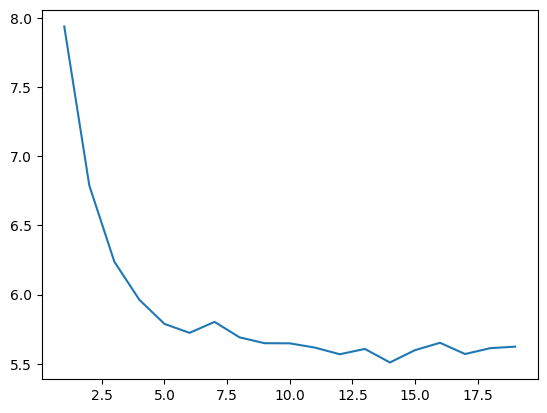

In [15]:
# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

### Entrenamiento LSTM

/home/rodri/venvs/venv_cuda/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 2.8409
 mean perplexity: 9.516346783349007 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 158s 218ms/step - loss: 2.5824
Epoch 2/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 2.2601
 mean perplexity: 8.295174878052991 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 151s 215ms/step - loss: 2.2257
Epoch 3/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 2.1449
 mean perplexity: 7.8204096134262855 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 151s 216ms/step - loss: 2.1252
Epoch 4/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 2.0752
 mean perplexity: 7.543030845998514 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 151s 215ms/step - loss: 2.0607
Epoch 5/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 2.0220
 mean perplexity: 7.2625484839834344 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 152s 216ms/step - loss: 2.0109
Epoch 6/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 1.9782
 mean per

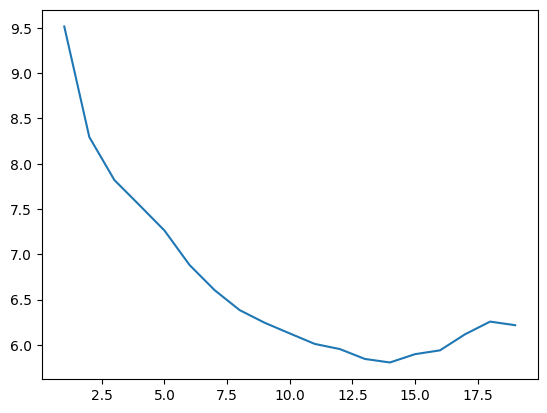

In [16]:
history_ppl = []
model = generate_lstm_model()
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl, model_name='lstm')], batch_size=256)


# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

### Entrenamiento GRU

/home/rodri/venvs/venv_cuda/lib/python3.12/site-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 2.6971
 mean perplexity: 8.238442669011127 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 150s 208ms/step - loss: 2.4238
Epoch 2/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 2.1288
 mean perplexity: 6.886327310041948 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - loss: 2.0784
Epoch 3/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 1.9479
 mean perplexity: 6.190582130894517 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - loss: 1.9124
Epoch 4/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 1.8192
 mean perplexity: 5.811040172673235 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - loss: 1.7947
Epoch 5/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 1.7299
 mean perplexity: 5.588076291662274 

Saved new model!
703/703 ━━━━━━━━━━━━━━━━━━━━ 141s 201ms/step - loss: 1.7115
Epoch 6/20
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 1.6648
 mean perpl

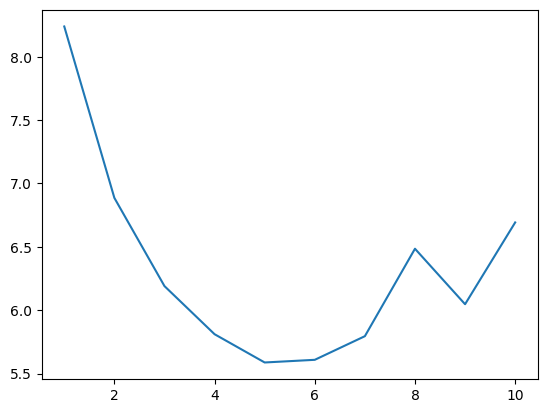

In [17]:
history_ppl = []
model = generate_gru_model()
hist = model.fit(X, y, epochs=20, callbacks=[PplCallback(tokenized_sentences_val,history_ppl, model_name='gru')], batch_size=256)


# Entrenamiento
epoch_count = range(1, len(history_ppl) + 1)
sns.lineplot(x=epoch_count,  y=history_ppl)
plt.show()

Si analizamos los tres modelos, podemos ver que en principio el que presenta mejor desempeño es el simple RNN. No solo logra una mejor métrica que los demás sino que lo logró en un tiempo de entrenamiento mucho menor: mientras los modelos con LSTM y GRU demoran aproximadamente 40 minutos en entrenar, RNN demora menos de 5 minutos. 

Es importante mencionar que en este caso, no se realizaron modificaciones ni de la estructura general de la red, ni de los hiperparámetros que la componen; unicamente se buscó el efecto que tendría sobre el desempeño del modelo la modificación de la capa intermedia (RNN, GRU o LSTM), manteniendo constante los hiperparámetros que la componen(numeros de unidades, dropout, etc).

Ante este escenario, se encontró que la que mejor desempeño tuvo fue el modelo que utilizó la capa Simple RNN, tanto en tiempo como en métrica de performance. Es probable que los otros modelos mejoren su desempeño, al ajustar hiperparámetros, como también modificar la estructura interna del modelo. 

## 4)Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.

Para evaluar esta sección cargaremos los tres modelo entrenados, y compararemos la secuencia generada para algunas frases fijas. Esto lo haremos tanto utilizando greedy search como beam search.

In [20]:
# Cargamos los modelos entrenados
modelo_rnn = keras.models.load_model('simple_rnn.keras')

modelo_lstm = keras.models.load_model('lstm.keras')

modelo_gru = keras.models.load_model('gru.keras')

### Generación de secuencias

In [21]:
def generate_seq(model, seed_text, max_length, n_words):
    """
        Exec model sequence prediction

        Args:
            model (keras): modelo entrenado
            seed_text (string): texto de entrada (input_seq)
            max_length (int): máxima longitud de la sequencia de entrada
            n_words (int): números de caracteres a agregar a la sequencia de entrada
        returns:
            output_text (string): sentencia con las "n_words" agregadas
    """
    output_text = seed_text
	# generate a fixed number of words
    for _ in range(n_words):
		# Encodeamos
        encoded = [char2idx[ch] for ch in output_text.lower() ]
		# Si tienen distinto largo
        encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

		# Predicción softmax
        y_hat = np.argmax(model.predict(encoded,verbose=0)[0,-1,:])
		# Vamos concatenando las predicciones
        out_word = ''

        out_word = idx2char[y_hat]

		# Agrego las palabras a la frase predicha
        output_text += out_word
    return output_text

### Resultados rnn

In [36]:
input_text='una tarde muy calurosa de verano'

generate_seq(modelo_rnn, input_text, max_length=max_context_size, n_words=50)

'una tarde muy calurosa de verano de la casa de la casa de la casa de la casa de la'

In [25]:
input_text='En rusia yo'

generate_seq(modelo_rnn, input_text, max_length=max_context_size, n_words=50)

'En rusia yo estaba en el cabeza de la casa de la casa de la c'

In [27]:
input_text='Estaba en la casa y'

generate_seq(modelo_rnn, input_text, max_length=max_context_size, n_words=50)

'Estaba en la casa y de la casa de la casa de la casa de la casa de la'

### Resultados LSTM

In [38]:
input_text='una tarde muy calurosa de verano'

generate_seq(modelo_lstm, input_text, max_length=max_context_size, n_words=50)

'una tarde muy calurosa de verano de la cabeza de la cabeza de la cabeza de la cabe'

In [29]:
input_text='En rusia yo'

generate_seq(modelo_lstm, input_text, max_length=max_context_size, n_words=50)

'En rusia yo estaba en el carto de la cabeza de la cabeza de l'

In [30]:
input_text='Estaba en la casa y'

generate_seq(modelo_lstm, input_text, max_length=max_context_size, n_words=50)

'Estaba en la casa y se le había de la cabeza de la cabeza de la cabez'

### Resultados gru

In [37]:
input_text='una tarde muy calurosa de verano'

generate_seq(modelo_gru, input_text, max_length=max_context_size, n_words=50)

'una tarde muy calurosa de veranos de la casa. en el cabeza de la casa. en el cabez'

In [32]:
input_text='En rusia yo'

generate_seq(modelo_gru, input_text, max_length=max_context_size, n_words=50)

'En rusia yo se le había de la casa. en el cabeza de la casa. '

In [33]:
input_text='Estaba en la casa y'

generate_seq(modelo_gru, input_text, max_length=max_context_size, n_words=50)

'Estaba en la casa y se le había de la casa. en el cabeza de la casa. '

### Resultado

Como podemos ver, el desempeño del modelo por si mismo no es el idea. Si analizamos los tres casos, vemos como estos se quedan trabados en secuencias al utilizar `de`, donde entran en una secuencia que no pueden salir. En primer instancia, creo que puede ser por que el modelo, al predecir en base a caracteres, es posible que necesite ventanas de contexto mas grandes para mejorar la lógica de las secuencias realizadas. 

Este caso es interesante de analizar, ya que el relato en si lo relata una persona que repite mucho sus ideas, que pasa el mayor tiempo en su casa enfermo o encerrado. Creo que lo que puede estar sucediendo es que las palabras casa y cabeza pueden llegar a estar sobrerepresentadas, por lo que le provoca que el modelo entre en estos loops de generación.

### Pruebas con Beam search y muestreo aleatorio

In [39]:
# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

In [40]:
from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

Para analizar este caso, haremos las pruebas para cada modelo con los mismos parámetros: 10 beams, 50 palabras, variando la temperatura. Usaremos para temperatura 1 y 10, y verificaremos como esto afecta al resultado final.

### RNN

In [58]:
input_text='una tarde muy calurosa de verano'

In [65]:
# predicción con beam search
salidas = beam_search(modelo_rnn,num_beams=10,num_words=50,input=input_text, temp=1)
decode(salidas[0])

'una tarde muy calurosa de verano de los ojos de los ojos de los ojos de la puerta '

In [64]:
salidas = beam_search(modelo_rnn,num_beams=10,num_words=50,input=input_text, temp=10)
decode(salidas[0])

'una tarde muy calurosa de verano de los ojos de los ojos de los ojos de la puerta '

### LSTM

In [66]:
# predicción con beam search
salidas = beam_search(modelo_lstm,num_beams=10,num_words=50,input=input_text, temp=1)
decode(salidas[0])

'una tarde muy calurosa de verano de la puerta de la puerta de la puerta de la viej'

In [68]:
# predicción con beam search
salidas = beam_search(modelo_lstm,num_beams=10,num_words=50,input=input_text, temp=10)
decode(salidas[2])

'una tarde muy calurosa de verano de la puerta de la puerta de la puerta de la cabe'

### GRU

In [69]:
# predicción con beam search
salidas = beam_search(modelo_gru,num_beams=10,num_words=50,input=input_text, temp=1)
decode(salidas[2])

'una tarde muy calurosa de veranos de la vieja de la vieja de la cabeza de la vieja'

In [70]:
# predicción con beam search
salidas = beam_search(modelo_gru,num_beams=10,num_words=50,input=input_text, temp=10)
decode(salidas[2])

'una tarde muy calurosa de veranos de la vieja de la vieja de la cabeza de la vieja'

A partir de los resultados obtenidos, observamos que la variación en la temperatura no produce modificaciones significativas en el comportamiento del modelo. Esto puede deberse, como se mencionó previamente, a un sobreajuste durante el entrenamiento: palabras como vieja, cabeza, casa, entre otras, parecen haber adquirido una probabilidad de aparición sustancialmente superior al resto. En consecuencia, incluso al modificar la temperatura, no se logra un aumento relevante en la variabilidad del modelo, ya que ciertas palabras dominan de forma persistente la generación.

Frente a esta problemática, las posibles soluciones dependerán del objetivo del entrenamiento. Si se busca obtener un modelo con menor grado de repeticiones, una estrategia viable sería ampliar el conjunto de datos, procurando que no esté conformado por una obra tan particular como Crimen y castigo. Asimismo, podría considerarse una reducción deliberada en la frecuencia de ciertas palabras durante el preprocesamiento, con el fin de evitar ciclos reiterativos. Otra alternativa es incrementar el tamaño de la ventana de contexto, lo cual podría contribuir a disminuir el peso de las repeticiones en la generación textual.

Como se ha señalado, la obra utilizada posee características muy específicas que la vuelven inadecuada como único dataset para el entrenamiento de un modelo de lenguaje general.